### Load Data

This cell loads the `dataset.csv` file into a pandas DataFrame named `df`. This is the initial step for importing our data into the notebook for further analysis.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/dataset.csv')
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


### Check for Missing Values

This cell checks for any missing values across all columns in the DataFrame `df`. It's crucial to identify and handle missing data before proceeding with analysis or model training.

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Smoking,0
Hx Smoking,0
Hx Radiothreapy,0
Thyroid Function,0
Physical Examination,0
Adenopathy,0
Pathology,0
Focality,0


### Display DataFrame Information

This cell provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This helps in understanding the structure and completeness of the data.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

### Display Descriptive Statistics

This cell generates descriptive statistics for the numerical columns in the DataFrame. It provides insights into the central tendency, dispersion, and shape of the distribution of each column.

In [ ]:
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


### Encode Binary Categorical Features

This step encodes binary categorical features ('Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Recurred') by replacing 'No' with 0 and 'Yes' with 1. This converts these text-based categories into a numerical format suitable for machine learning models.

In [ ]:
df_col_replaced = df[['Smoking', 'Hx Smoking', 'Hx Radiothreapy','Recurred']].replace({'No': 0, 'Yes': 1})

/tmp/ipython-input-2196703484.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_col_replaced = df[['Smoking', 'Hx Smoking', 'Hx Radiothreapy','Recurred']].replace({'No': 0, 'Yes': 1})


### One-Hot Encode Other Categorical Features

This cell uses one-hot encoding for the remaining categorical features. `pd.get_dummies` creates new binary columns for each category, which is necessary for most machine learning algorithms. `drop_first=True` is used to avoid multicollinearity.

In [ ]:
Columns_to_encode = df[['Age', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology','Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']]
df_col_encoded = pd.get_dummies(Columns_to_encode, drop_first = True)

### Combine Encoded Data and Map Gender

Here, the numerically encoded binary features (`df_col_replaced`) and one-hot encoded features (`df_col_encoded`) are concatenated. Additionally, the 'Gender' column is mapped to numerical values (0 for Male, 1 for Female) and added to the combined DataFrame `df2`.

In [ ]:
df2 = pd.concat([df_col_replaced, df_col_encoded], axis = 1)
df2['Gender'] = df['Gender'].map({'M': 0, 'F':1})
df2.head()

,Smoking,Hx Smoking,Hx Radiothreapy,Recurred,Age,Thyroid Function_Clinical Hypothyroidism,Thyroid Function_Euthyroid,Thyroid Function_Subclinical Hyperthyroidism,Thyroid Function_Subclinical Hypothyroidism,Physical Examination_Multinodular goiter,...,N_N1b,M_M1,Stage_II,Stage_III,Stage_IVA,Stage_IVB,Response_Excellent,Response_Indeterminate,Response_Structural Incomplete,Gender
0,0,0,0,0,27,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,1
1,0,1,0,0,34,False,True,False,False,True,...,False,False,False,False,False,False,True,False,False,1
2,0,0,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,1
3,0,0,0,0,62,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,1
4,0,0,0,0,62,False,True,False,False,True,...,False,False,False,False,False,False,True,False,False,1


### Visualize Feature Correlations

This code generates a heatmap to visualize the correlation matrix of `df2`. A heatmap helps in understanding the linear relationships between all pairs of features in the dataset, which can be useful for feature selection.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

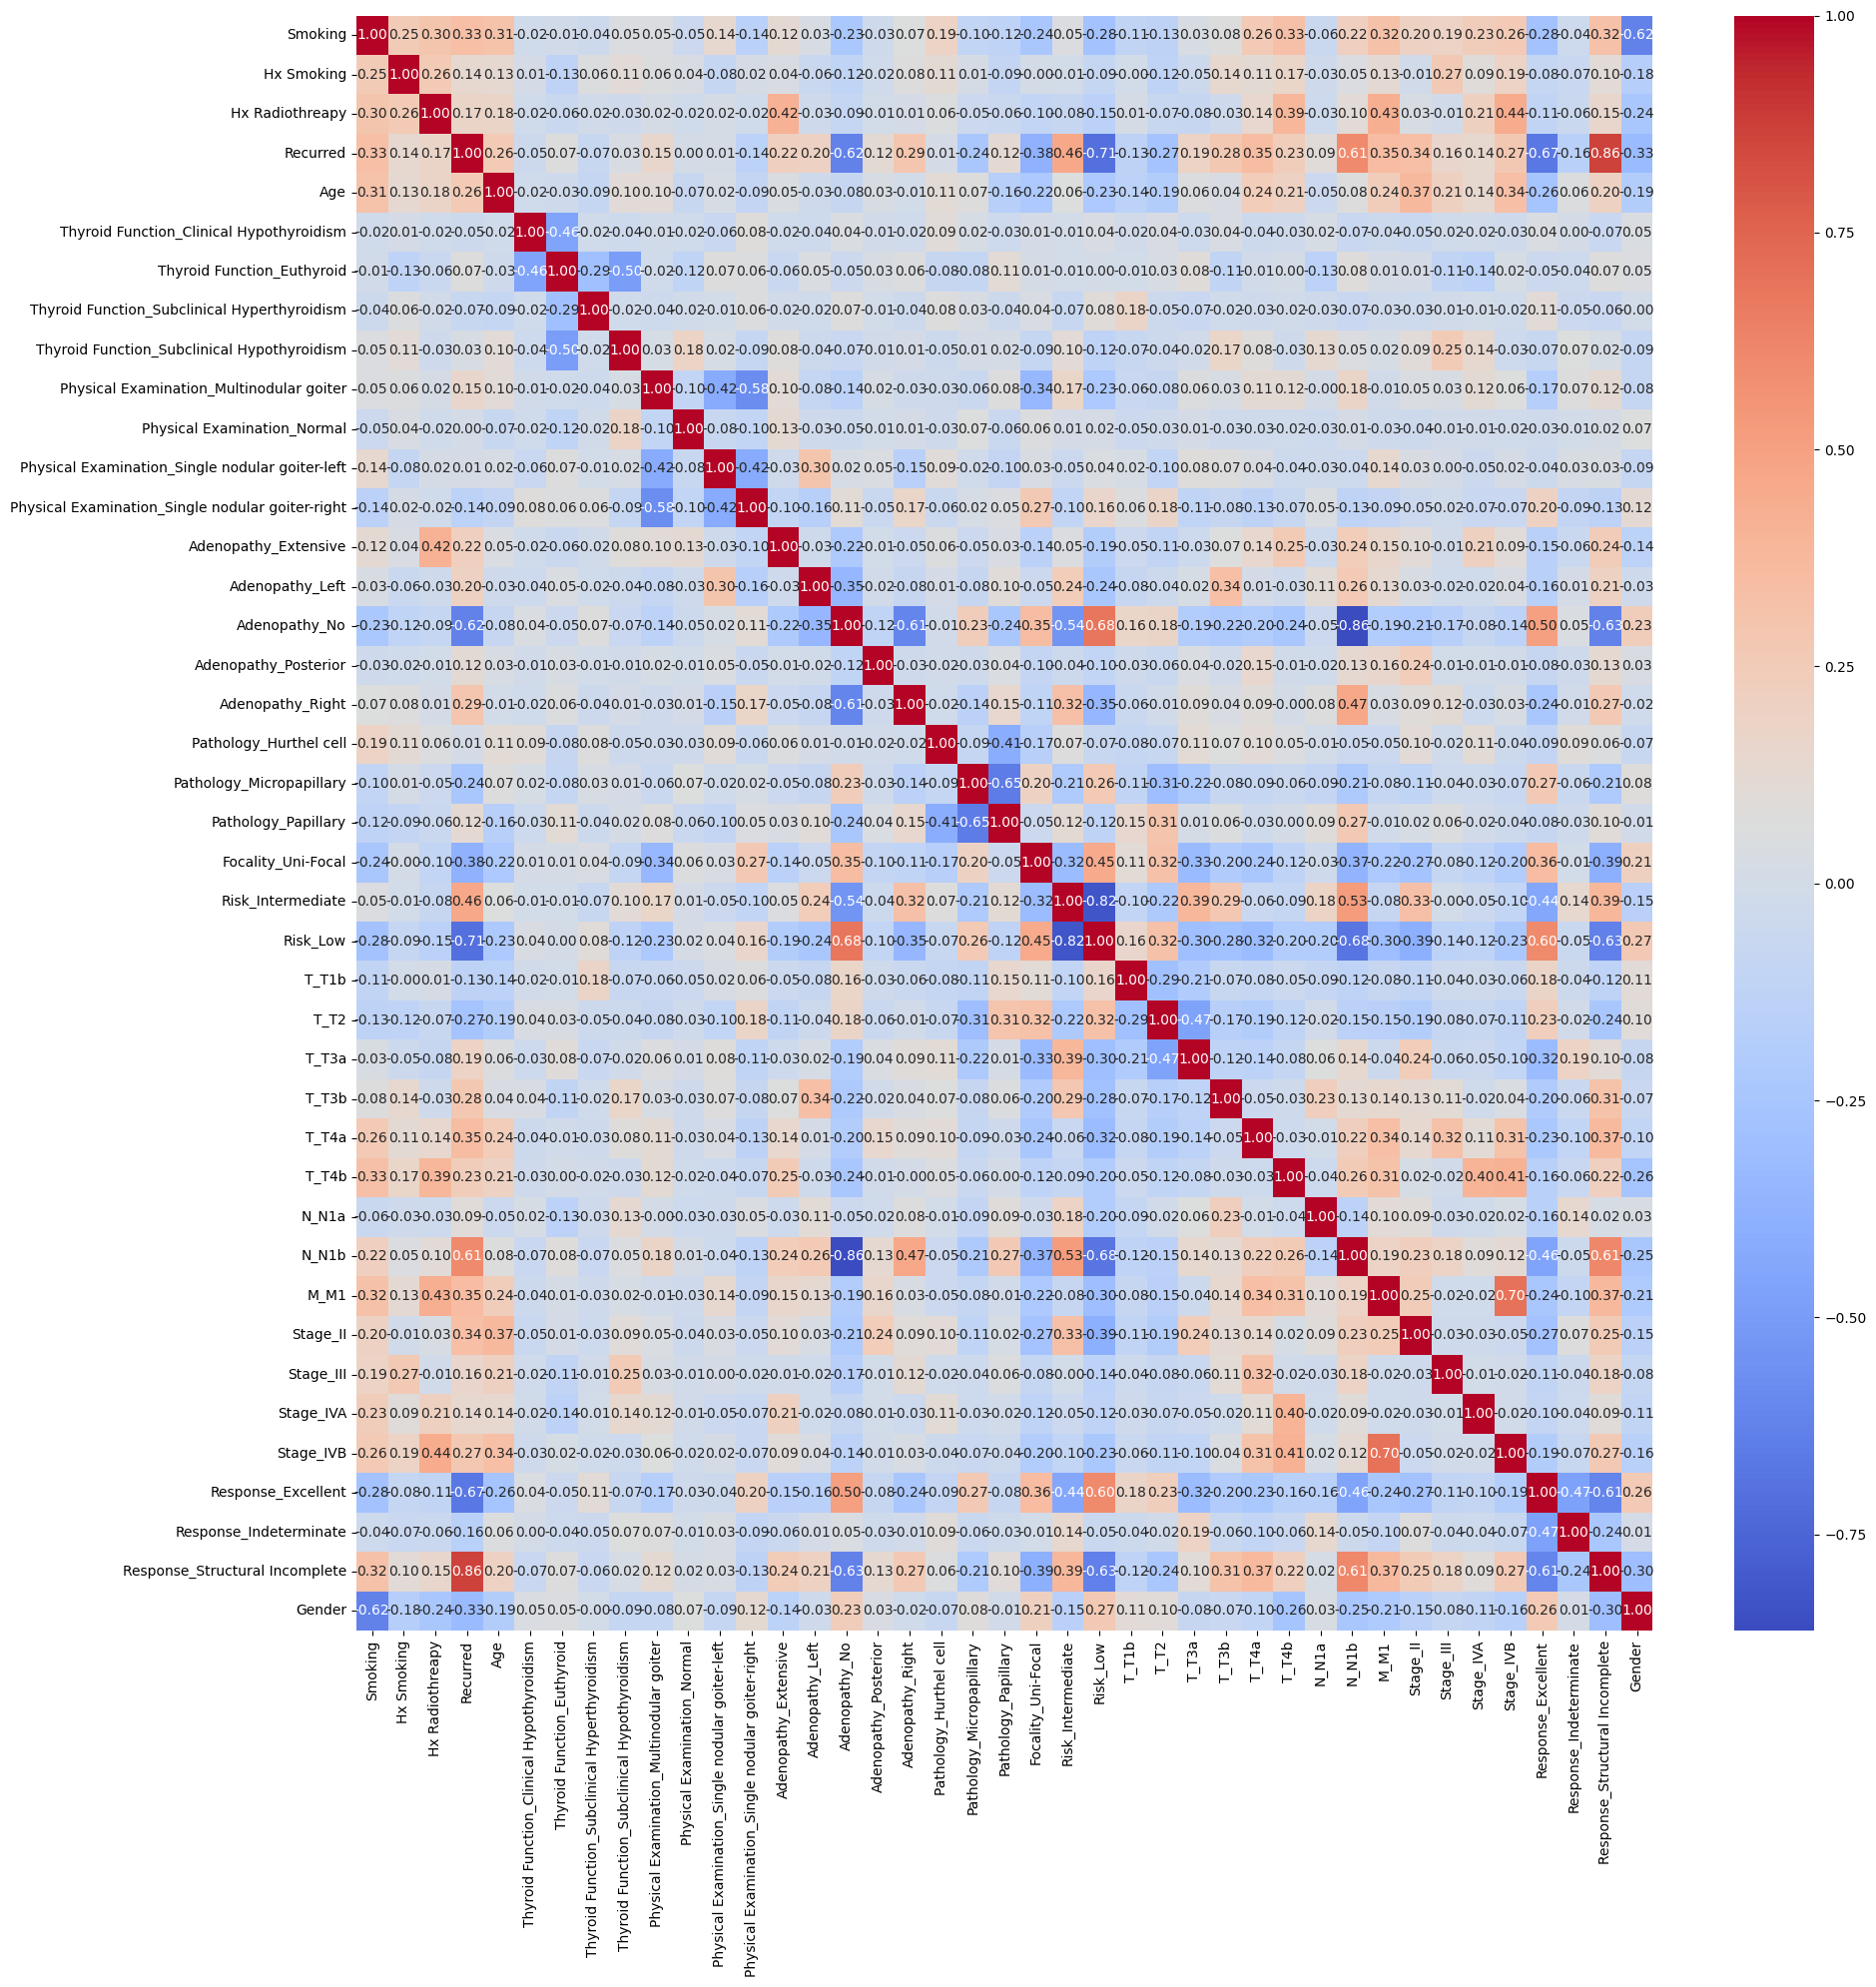

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df2.corr(), annot = True, fmt= '.2f', cmap='coolwarm')
plt.xticks(rotation= 90)
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

### 1. Distribution of 'Age'

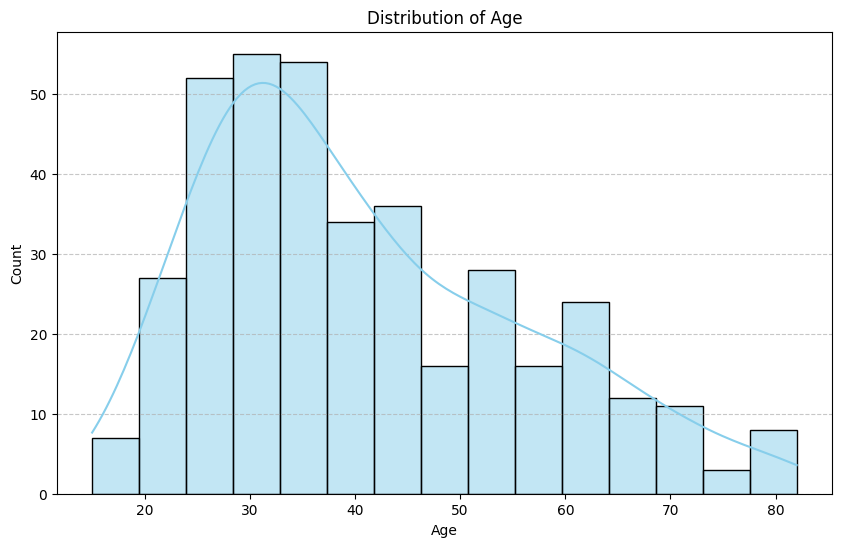

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df2['Age'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Counts of 'Gender' and 'Recurred'

/tmp/ipython-input-2666272353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df2, ax=axes[0], palette='viridis')
/tmp/ipython-input-2666272353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Recurred', data=df2, ax=axes[1], palette='plasma')


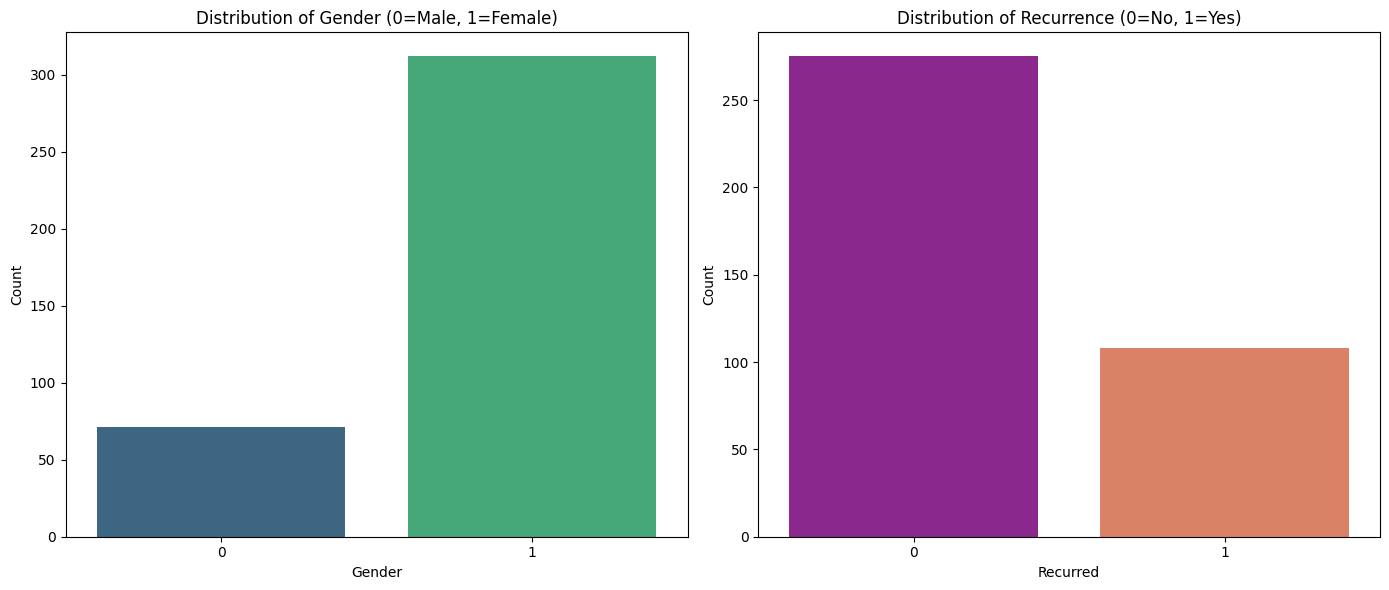

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='Gender', data=df2, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Gender (0=Male, 1=Female)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

sns.countplot(x='Recurred', data=df2, ax=axes[1], palette='plasma')
axes[1].set_title('Distribution of Recurrence (0=No, 1=Yes)')
axes[1].set_xlabel('Recurred')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3. Relationship between Key Categorical Features and 'Recurred'


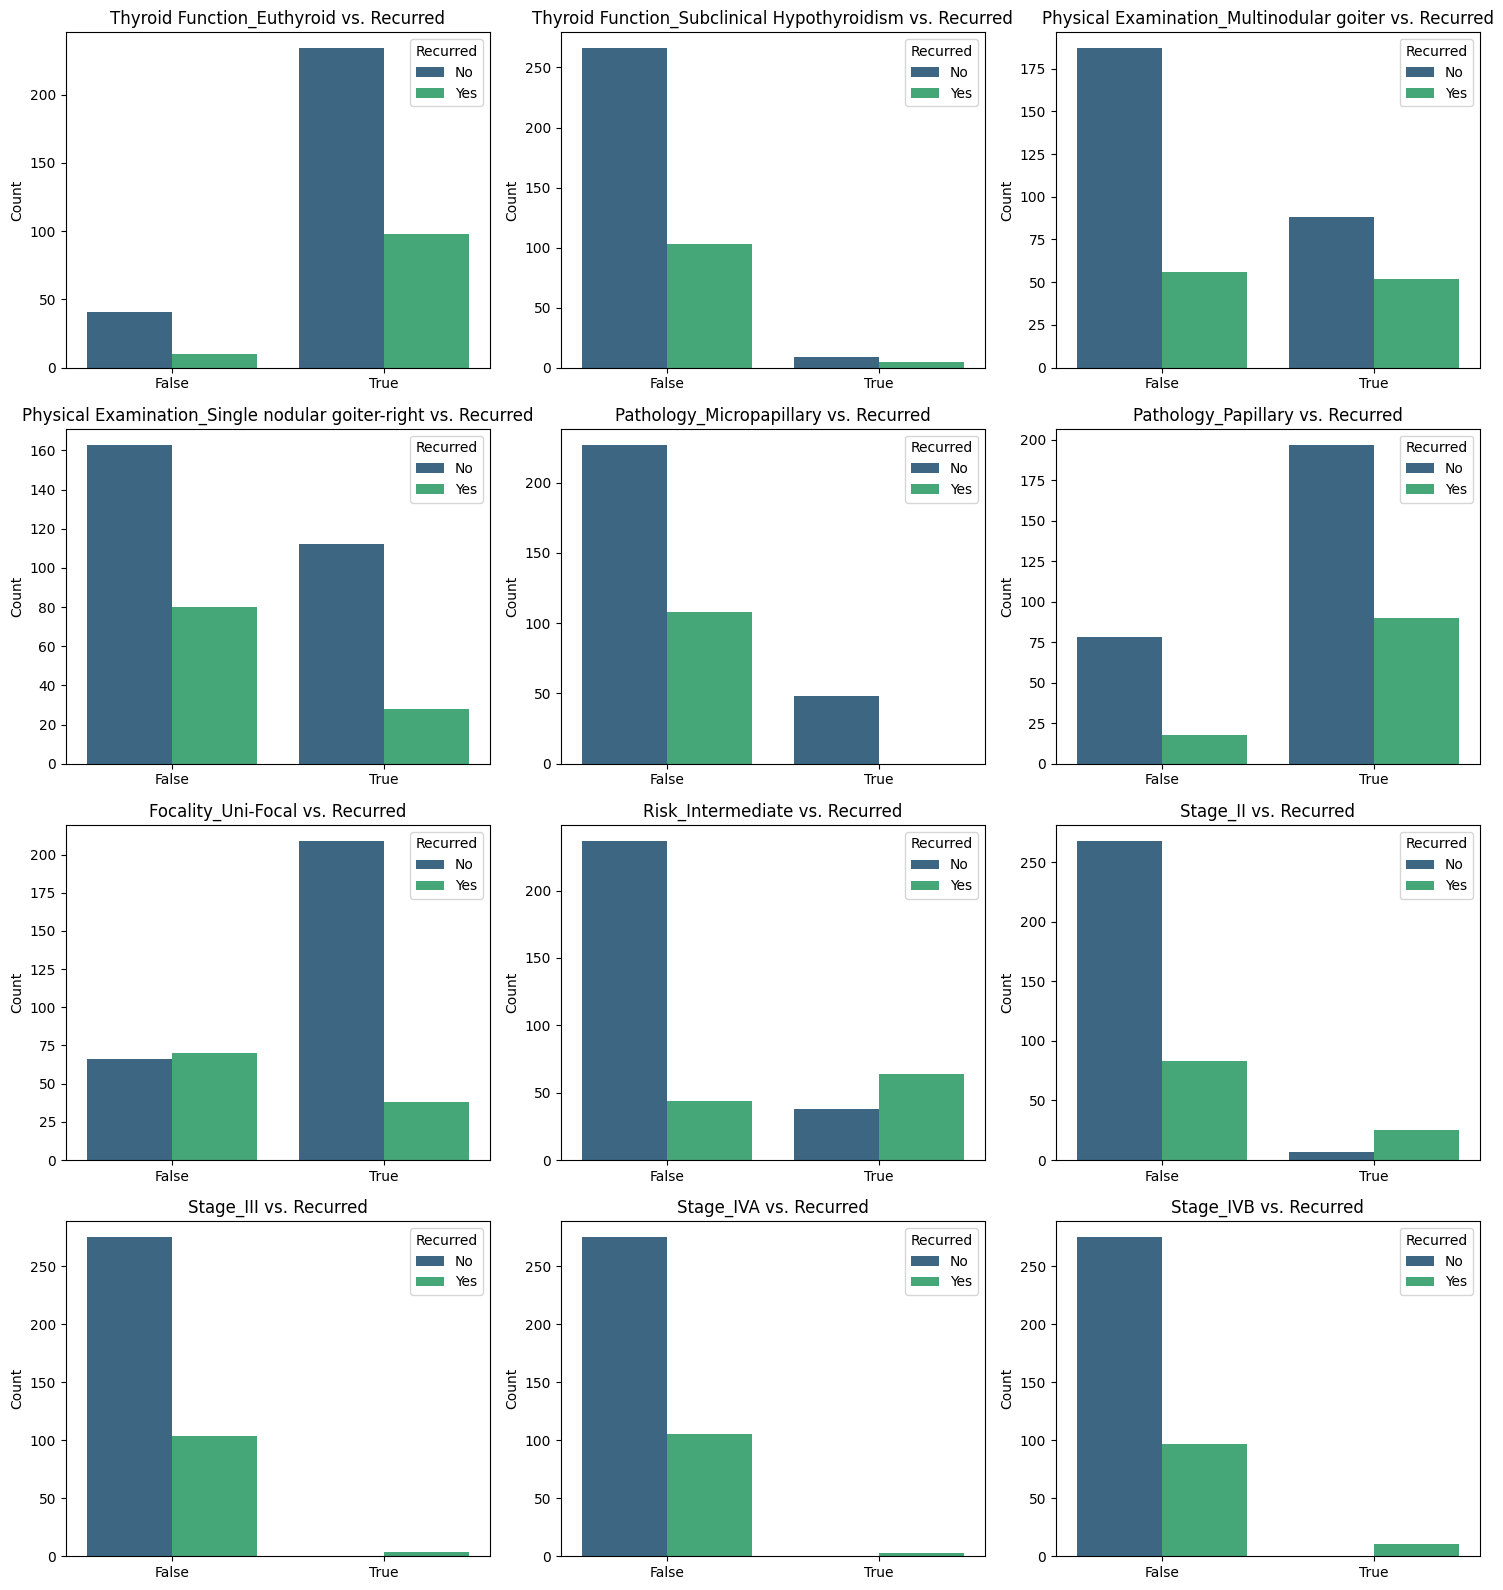

In [ ]:
categorical_features_to_plot = [
    'Thyroid Function_Euthyroid',
    'Thyroid Function_Subclinical Hypothyroidism',
    'Physical Examination_Multinodular goiter',
    'Physical Examination_Single nodular goiter-right',
    'Pathology_Micropapillary',
    'Pathology_Papillary',
    'Focality_Uni-Focal', # Changed from 'Focality_Multi-Focal'
    'Risk_Intermediate',
    'Stage_II',
    'Stage_III',
    'Stage_IVA',
    'Stage_IVB'
]

# Create subplots based on the number of features
num_features = len(categorical_features_to_plot)
num_cols = 3 # Number of columns for the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feature in enumerate(categorical_features_to_plot):
    sns.countplot(x=feature, hue='Recurred', data=df2, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{feature} vs. Recurred')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Recurred', labels=['No', 'Yes'])

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Analyze Outliers in 'Age' using IQR

This cell calculates the Interquartile Range (IQR) for the 'Age' column. The IQR is used to determine the lower and upper bounds, which helps in identifying potential outliers in the age distribution.

In [ ]:
Q1_age = df2['Age'].quantile(0.25)
Q3_age = df2['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_bound = Q1_age - (1.5*IQR_age)
upper_bound = Q3_age + (1.5*IQR_age)
print('Minimum age :', df2['Age'].min())
print('Maximum age :', df2['Age'].max())
print('IQR value of Age :',IQR_age)
print('Lower bound :', lower_bound)
print('Upper bound :', upper_bound)

Minimum age : 15
Maximum age : 82
IQR value of Age : 22.0
Lower bound : -4.0
Upper bound : 84.0


### Prepare Data for Modeling (Features and Target)

This step separates the DataFrame `df2` into features (X) and the target variable (y). 'Recurred' is our target, and all other columns are used as features to predict recurrence.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

In [ ]:
X = df2.drop('Recurred', axis=1)
y = df2['Recurred']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 42)

### Initialize and Train Logistic Regression Model

This code initializes a Logistic Regression model and then trains it using the `X_train` (features) and `y_train` (target) datasets. Logistic Regression is a common algorithm for binary classification problems.

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

### Evaluate Model Performance

This final step calculates and prints various performance metrics for the logistic regression model. This includes accuracy, precision, recall, a confusion matrix, and a classification report, providing a comprehensive view of how well the model performed.

In [ ]:
print('Accuracy Score : ', accuracy_score(y_test, y_pred))
print('Precision Score : ', precision_score(y_test, y_pred))
print('Recall Score : ', recall_score(y_test, y_pred))
print('Confusion Matrix : \n', confusion_matrix(y_test, y_pred))
print('Classification Report : \n', classification_report(y_test, y_pred))

Accuracy Score :  0.9652173913043478
Precision Score :  0.9375
Recall Score :  0.9375
Confusion Matrix : 
 [[81  2]
 [ 2 30]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        83
           1       0.94      0.94      0.94        32

    accuracy                           0.97       115
   macro avg       0.96      0.96      0.96       115
weighted avg       0.97      0.97      0.97       115



### Summary of Findings


**Data Overview and Preprocessing:**
- The `dataset.csv` file was loaded, containing 383 entries and 17 columns.
- Initial checks showed no missing values across all columns.
- Data types consisted primarily of one integer column (`Age`) and 16 object (categorical) columns.
- Categorical features were preprocessed:
    - Binary categorical features ('Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Recurred') were encoded to 0 (No) and 1 (Yes).
    - Other categorical features were one-hot encoded using `pd.get_dummies`.
    - The 'Gender' column was mapped to 0 (Male) and 1 (Female).

**Exploratory Data Analysis (EDA):**
- The distribution of 'Age' showed a range from 15 to 82, with a mean of approximately 40.87. An IQR analysis indicated that all age values were within the calculated bounds, suggesting no extreme outliers by this method.
- Visualizations provided insights into the distribution of 'Gender' (more females than males in the dataset) and 'Recurred' (fewer cases of recurrence).
- Correlations between various features were visualized using a heatmap, revealing relationships within the dataset.

**Logistic Regression Model Performance:**
- The data was split into training (70%) and testing (30%) sets.
- A Logistic Regression model was trained to predict 'Recurred'.
- The model achieved strong performance on the test set:
    - **Accuracy Score**: 0.965 (approximately 96.5%)
    - **Precision Score**: 0.938
    - **Recall Score**: 0.938
- **Confusion Matrix**:
  ```
  [[81  2]
   [ 2 30]]
  ```
  - The model correctly predicted 81 cases of 'No Recurrence' and 30 cases of 'Recurrence'.
  - There were 2 false positives (predicted recurrence, but no recurrence) and 2 false negatives (predicted no recurrence, but recurrence).
- **Classification Report**: Showed high precision, recall, and f1-score for both classes, indicating a robust model for predicting recurrence based on the provided features.

In conclusion, the logistic regression model demonstrated high effectiveness in predicting thyroid cancer recurrence based on the prepared features, with an accuracy exceeding 96% and balanced precision and recall for both outcome classes.